# Visualization

Chart templates for KanKyouKen event data:
- Daily activity timeline
- Event type distribution
- Participant heatmaps
- Hour-of-day and day-of-week patterns
- Interactive Plotly charts
- Publication-ready multi-panel figure

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
except ImportError:
    PLOTLY = False
    print("plotly not installed — interactive plots skipped")

from notebook_setup import setup

client, STUDY_ID, PARTICIPANT_IDS = setup(n_participants=5, n_events=100)

# Style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 120, "font.size": 11})

URL:          http://127.0.0.1:54321
Study:        090f8994-0b4b-46f7-b9f1-6012979bd31f
Participants: 5
Events:       100


## Load Data

In [2]:
import pandas as pd

df = pd.DataFrame([e.to_dict() for e in client.iter_events(study_id=STUDY_ID)])

df["ts"] = pd.to_datetime(df["ts"])
df["date"] = df["ts"].dt.normalize()
df["hour"] = df["ts"].dt.hour
df["dow"] = df["ts"].dt.dayofweek  # 0=Mon
df = df.sort_values("ts").reset_index(drop=True)

TOP_TYPES = df["event_type"].value_counts().head(6).index.tolist()
print(f"{len(df)} events loaded")

100 events loaded


## 1. Daily Activity Timeline

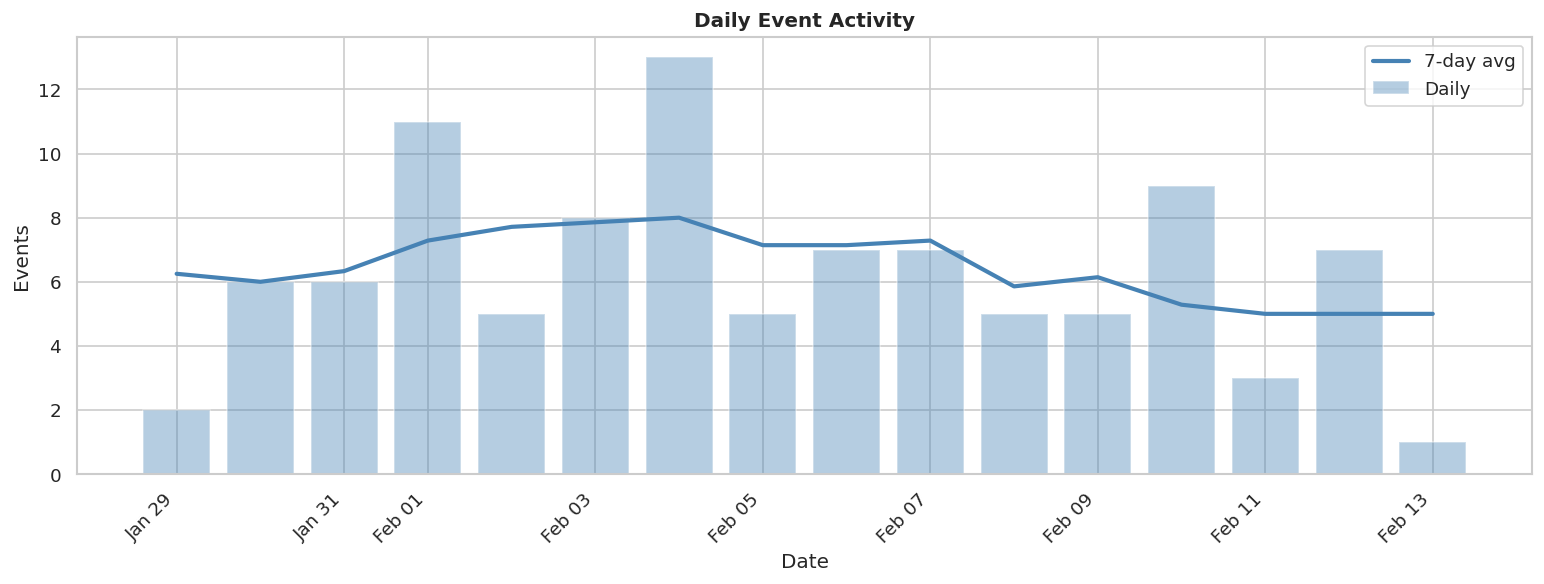

In [3]:
daily = df.groupby("date").size().rename("events").reset_index()
daily["ma7"] = daily["events"].rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots()
ax.bar(daily["date"], daily["events"], width=0.8, alpha=0.4, color="steelblue", label="Daily")
ax.plot(daily["date"], daily["ma7"], color="steelblue", lw=2.5, label="7-day avg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
ax.set_xlabel("Date")
ax.set_ylabel("Events")
ax.set_title("Daily Event Activity", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Event Type Distribution

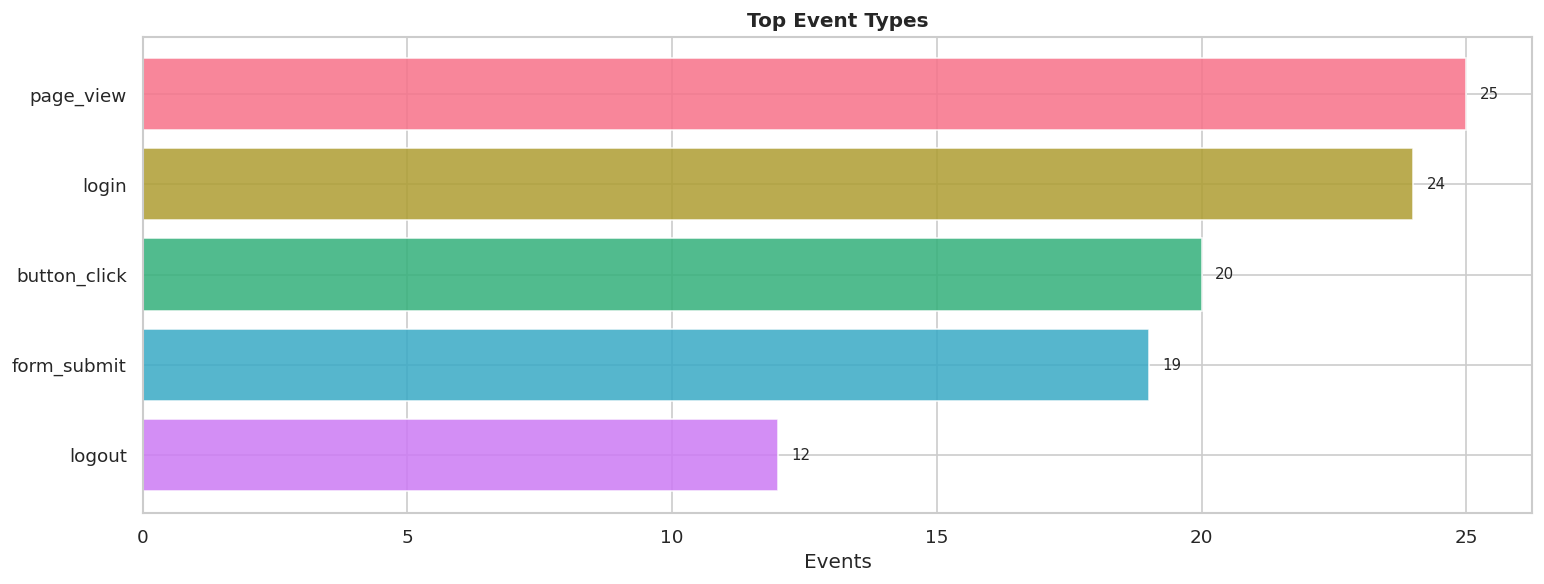

In [4]:
type_counts = df["event_type"].value_counts().head(10)

fig, ax = plt.subplots()
colors = sns.color_palette("husl", len(type_counts))
bars = ax.barh(range(len(type_counts)), type_counts.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(type_counts)))
ax.set_yticklabels(type_counts.index)
ax.invert_yaxis()
ax.set_xlabel("Events")
ax.set_title("Top Event Types", fontweight="bold")
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width() + max(type_counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Activity Heatmap (Hour x Day of Week)

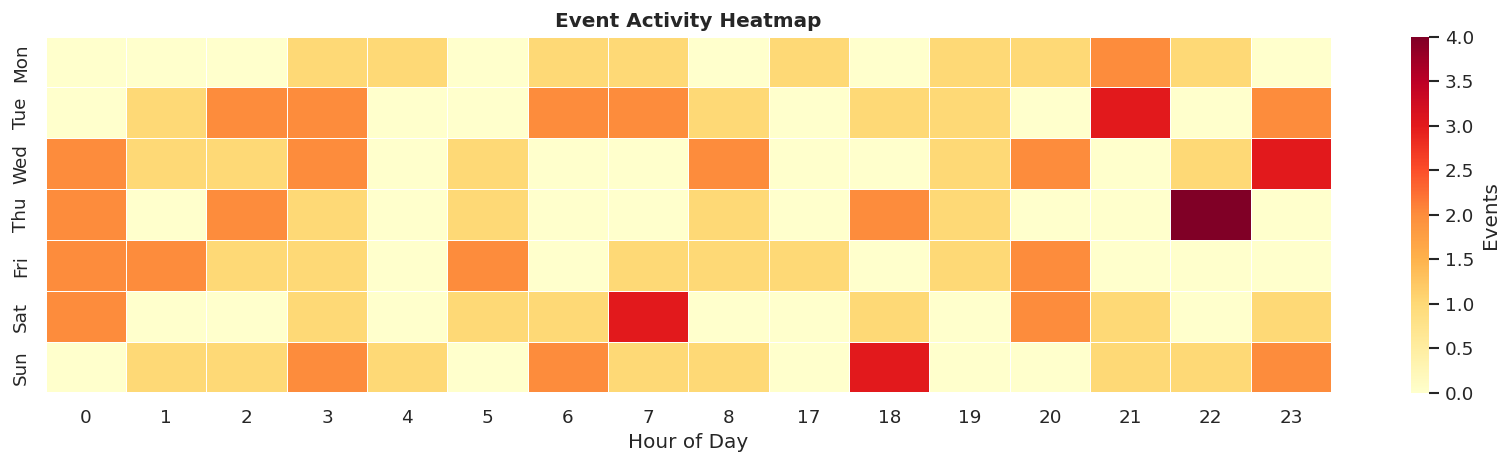

In [5]:
pivot = df.groupby(["dow", "hour"]).size().unstack(fill_value=0)
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:len(pivot)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Events"}, ax=ax)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
ax.set_title("Event Activity Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Participant x Event Type Engagement

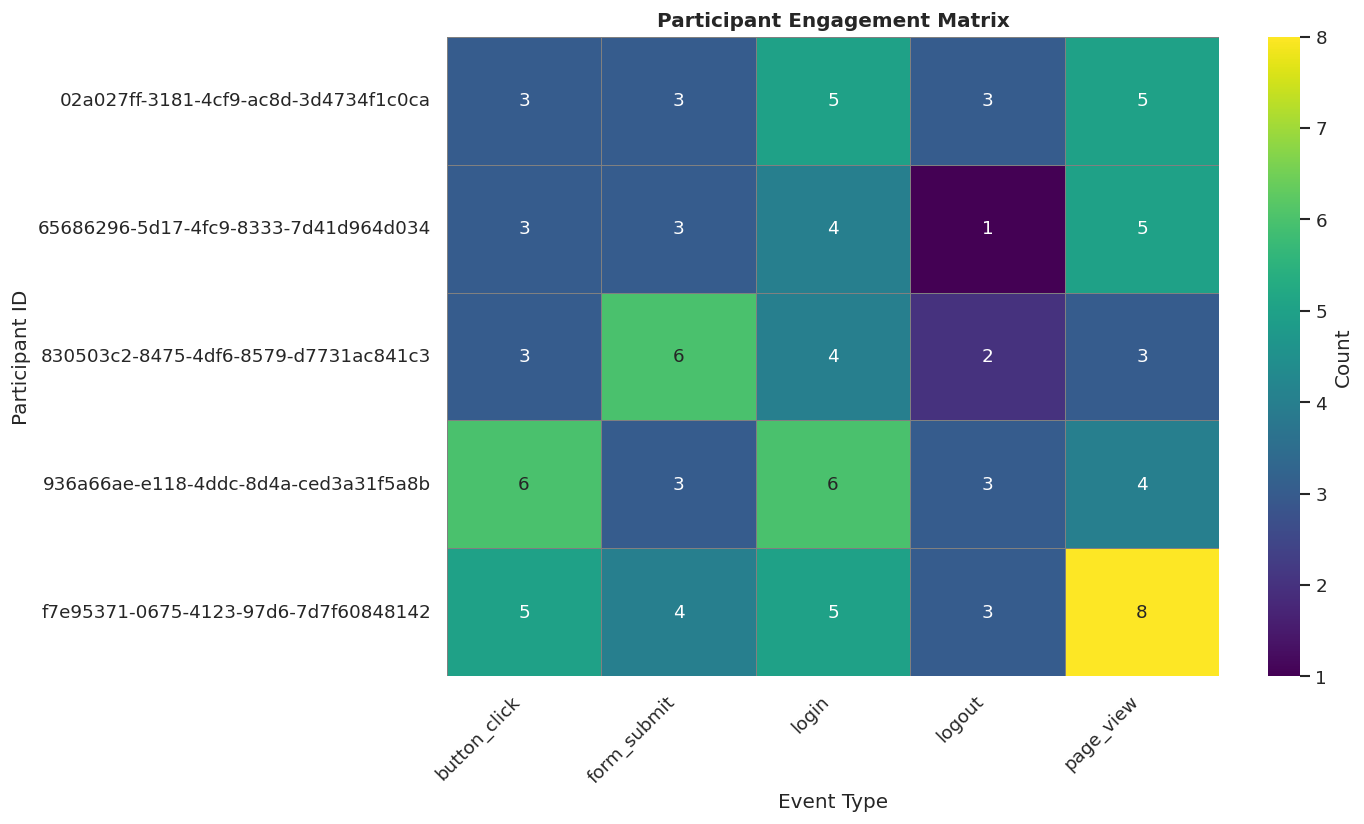

In [6]:
top_participants = df["participant_id"].value_counts().head(15).index
matrix = (
    df[df["participant_id"].isin(top_participants) & df["event_type"].isin(TOP_TYPES)]
    .groupby(["participant_id", "event_type"]).size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(matrix, cmap="viridis", annot=True, fmt=".0f",
            linewidths=0.3, linecolor="gray", cbar_kws={"label": "Count"}, ax=ax)
ax.set_xlabel("Event Type")
ax.set_ylabel("Participant ID")
ax.set_title("Participant Engagement Matrix", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Cumulative Events by Type

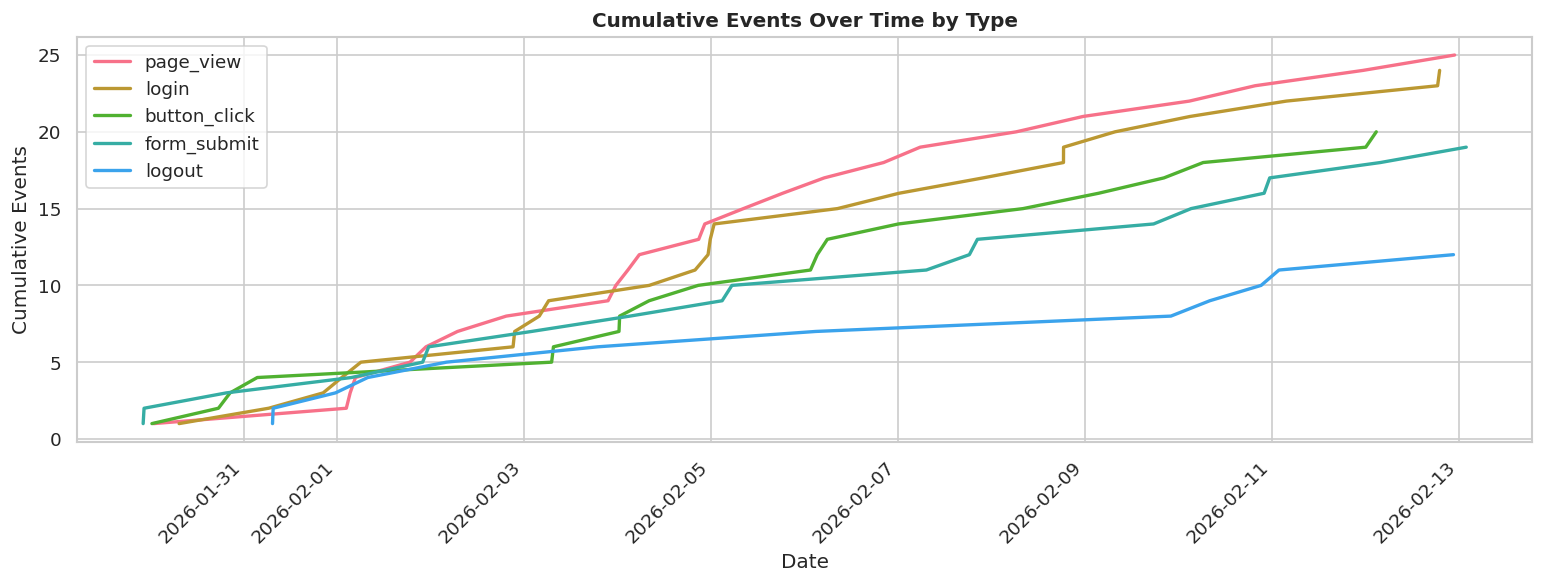

In [7]:
fig, ax = plt.subplots()
for event_type in TOP_TYPES:
    sub = df[df["event_type"] == event_type].copy()
    sub["cumulative"] = range(1, len(sub) + 1)
    ax.plot(sub["ts"], sub["cumulative"], lw=2, label=event_type)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Events")
ax.set_title("Cumulative Events Over Time by Type", fontweight="bold")
ax.legend(loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Events per Participant Distribution

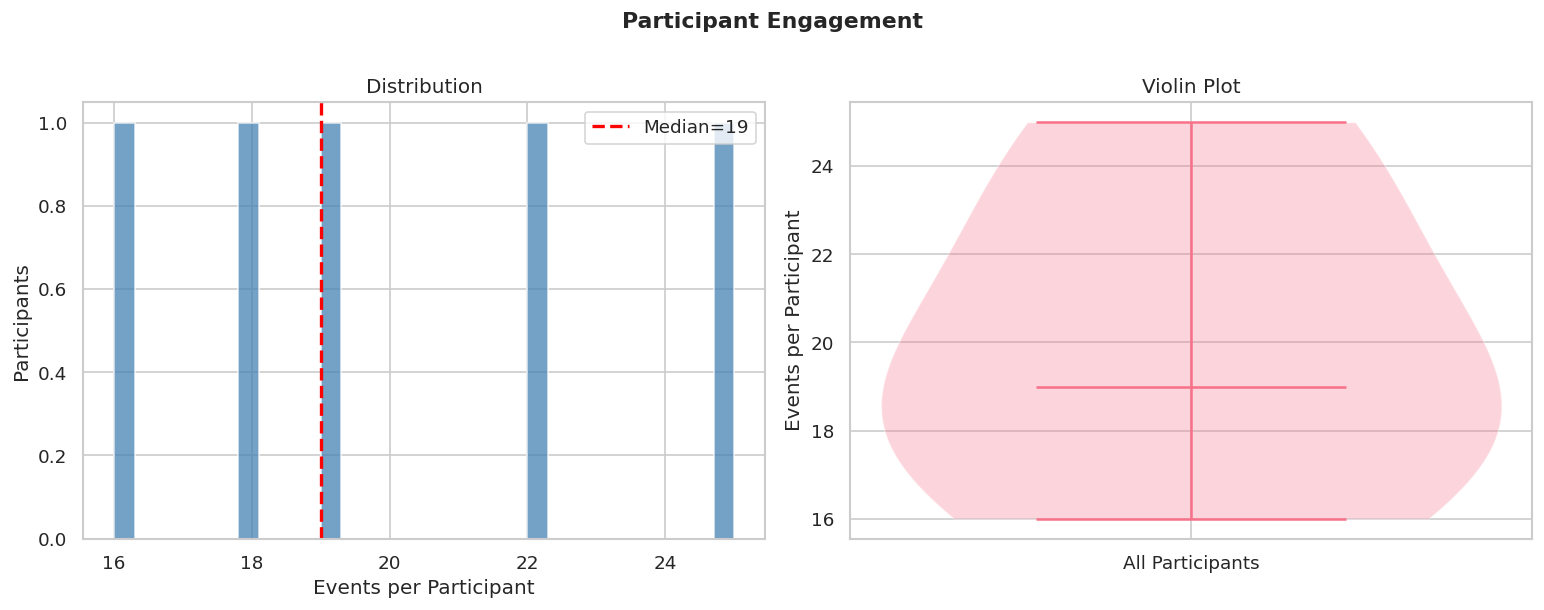

In [8]:
per_participant = df["participant_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(per_participant.values, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
axes[0].axvline(per_participant.median(), color="red", ls="--", lw=2,
                label=f"Median={per_participant.median():.0f}")
axes[0].set_xlabel("Events per Participant")
axes[0].set_ylabel("Participants")
axes[0].set_title("Distribution")
axes[0].legend()

# Violin
axes[1].violinplot([per_participant.values], positions=[0], showmedians=True, widths=0.6)
axes[1].set_xticks([0])
axes[1].set_xticklabels(["All Participants"])
axes[1].set_ylabel("Events per Participant")
axes[1].set_title("Violin Plot")

plt.suptitle("Participant Engagement", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Interactive Timeline (Plotly)

Requires pip install plotly.

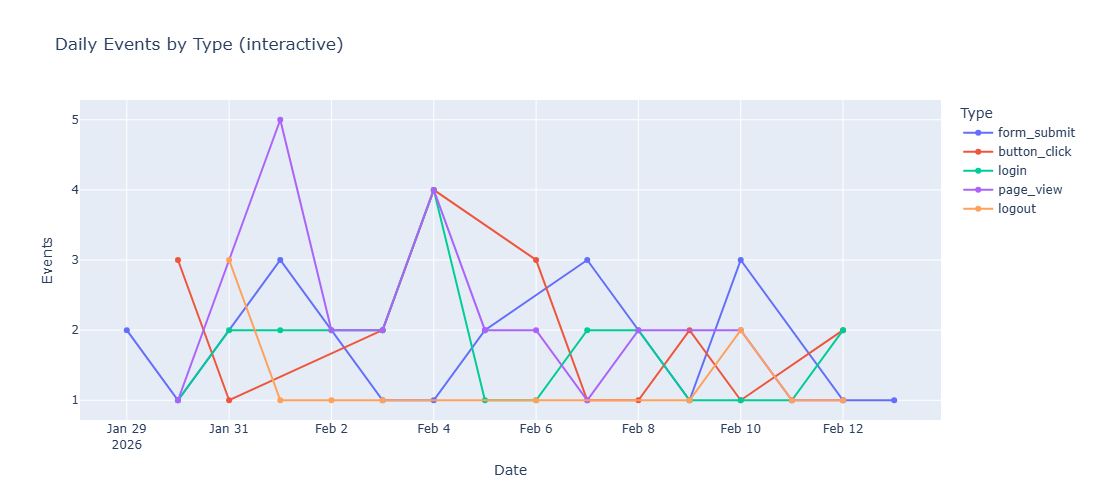

In [9]:
if PLOTLY:
    daily_by_type = (
        df[df["event_type"].isin(TOP_TYPES)]
        .groupby(["date", "event_type"]).size()
        .reset_index(name="count")
    )
    fig = px.line(
        daily_by_type, x="date", y="count", color="event_type",
        title="Daily Events by Type (interactive)",
        labels={"date": "Date", "count": "Events", "event_type": "Type"},
        height=500,
    )
    fig.update_traces(mode="lines+markers", line_width=2)
    fig.update_layout(hovermode="x unified")
    fig.show()
else:
    print("Install plotly to see interactive charts: pip install plotly")

## 8. Publication-Ready Multi-Panel Figure

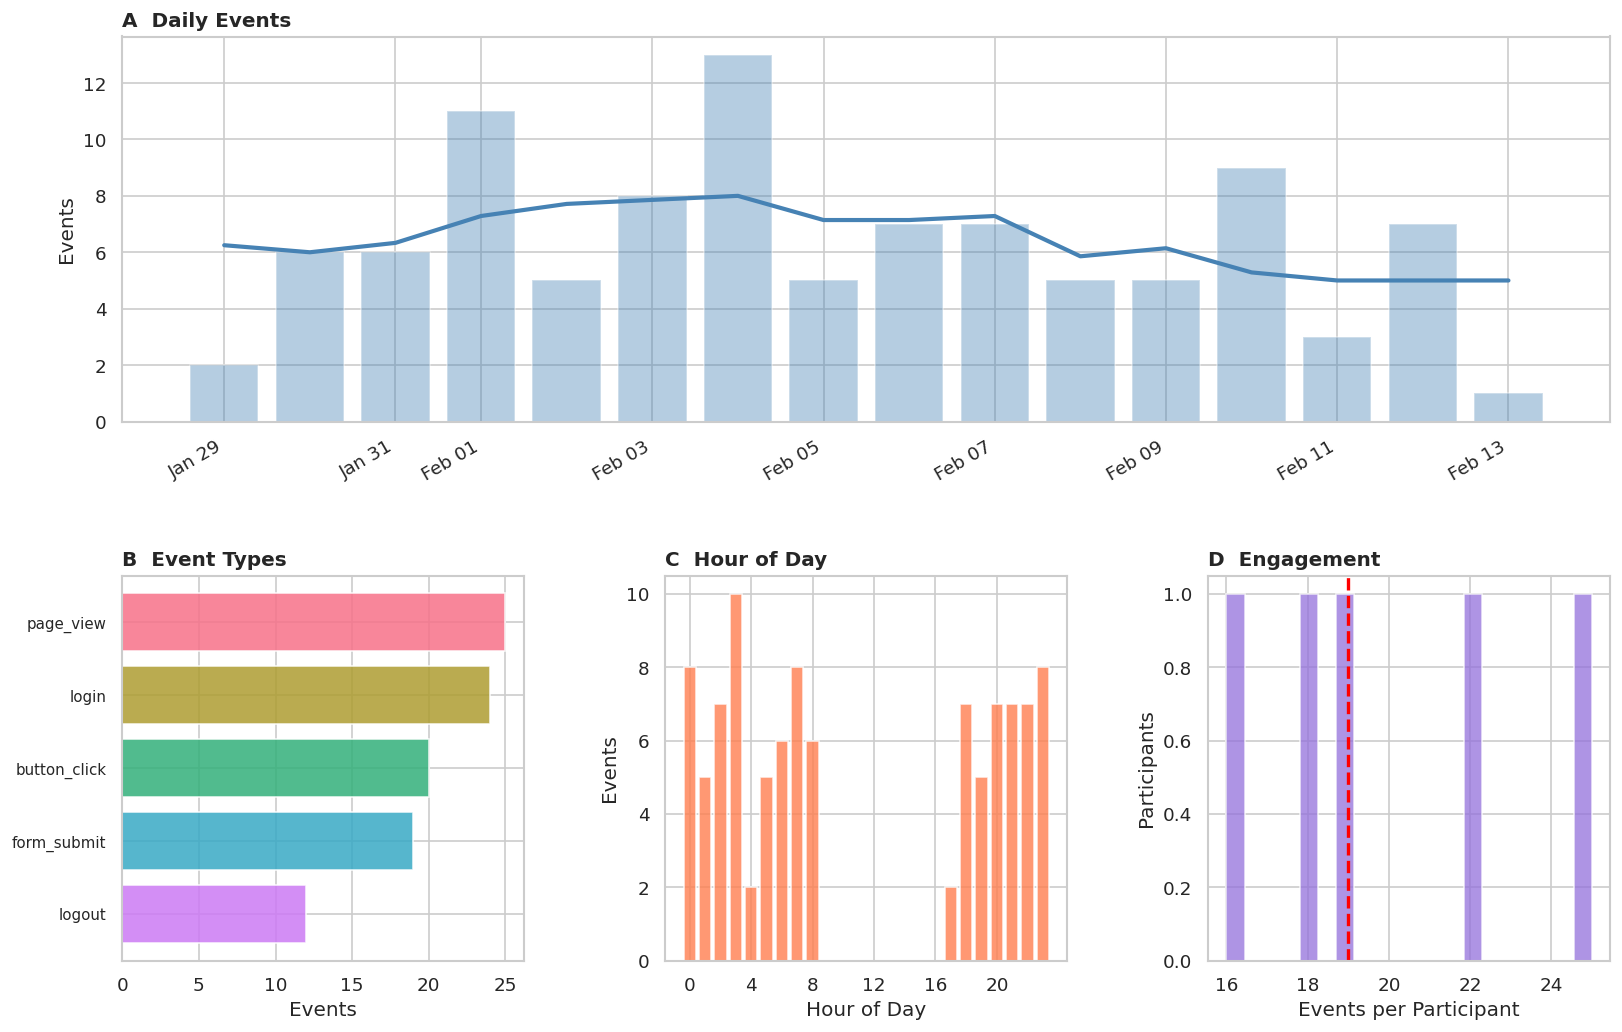

Saved to figures/


In [10]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# A: Daily activity
ax_a = fig.add_subplot(gs[0, :])
ax_a.bar(daily["date"], daily["events"], width=0.8, alpha=0.4, color="steelblue")
ax_a.plot(daily["date"], daily["ma7"], color="steelblue", lw=2.5)
ax_a.set_title("A  Daily Events", fontweight="bold", loc="left")
ax_a.set_ylabel("Events")
ax_a.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax_a.get_xticklabels(), rotation=30, ha="right")

# B: Event type bar
ax_b = fig.add_subplot(gs[1, 0])
tc = df["event_type"].value_counts().head(6)
ax_b.barh(range(len(tc)), tc.values, color=sns.color_palette("husl", len(tc)), alpha=0.85)
ax_b.set_yticks(range(len(tc)))
ax_b.set_yticklabels(tc.index, fontsize=9)
ax_b.invert_yaxis()
ax_b.set_xlabel("Events")
ax_b.set_title("B  Event Types", fontweight="bold", loc="left")

# C: Hourly
ax_c = fig.add_subplot(gs[1, 1])
hourly = df.groupby("hour").size()
ax_c.bar(hourly.index, hourly.values, color="coral", alpha=0.8, edgecolor="white")
ax_c.set_xlabel("Hour of Day")
ax_c.set_ylabel("Events")
ax_c.set_title("C  Hour of Day", fontweight="bold", loc="left")
ax_c.set_xticks(range(0, 24, 4))

# D: Participant distribution
ax_d = fig.add_subplot(gs[1, 2])
ax_d.hist(per_participant.values, bins=20, color="mediumpurple", alpha=0.75, edgecolor="white")
ax_d.axvline(per_participant.median(), color="red", ls="--", lw=2)
ax_d.set_xlabel("Events per Participant")
ax_d.set_ylabel("Participants")
ax_d.set_title("D  Engagement", fontweight="bold", loc="left")

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/study_overview.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/study_overview.pdf", bbox_inches="tight")
plt.show()
print("Saved to figures/")